# **LINEAR REGRESSION** (Sesi 5-6, 23 feb 2026 )
**Fadhlan Nur Rachman - 2802491690**

Data Dictionary:
https://github.com/JoannaBroniarek/House-Prices-Advanced-Regression-Techniques/blob/master/dane/data_description.txt

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv('house_pricing_regression/train.csv')
test_data = pd.read_csv('house_pricing_regression/test.csv')

print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


**Interpretasi cell diatas**:  
terdapat data train sebanyak (1460 baris dan 81 fitur) serta data test sebanyak (1459 baris dan 81 fitur) data


In [46]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Interpretasi cell diatas**:  
menampilkan informasi 5 baris awal data train dengan beberapa fitur

In [47]:
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


**Interpretasi cell diatas**:  
menampilkan informasi 5 baris awal data test dengan beberapa fitur

Fokus ke data training terlebih dahulu

# Exploratory Data Analysis

In [48]:
# Identify Training Data Structure

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**Interpretasi cell diatas**:  
menampilkan informasi tipe data dan juga banyak baris yang terisi dari setiap kolom.  
contoh: kolom Alley(gang) memiliki tipe data kategorikal(object) dengan data yang hanya terisi 91 baris

In [49]:
# Summary Statistics for Numerical Data

train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Interpretasi cell diatas**:  
melihat berbagai rangkuman statistik data numerik. <br>
contoh: SalePrice(harga jual) dari seluruh data yang ada mempunyai rata-rata 180921.19

In [50]:
# Summary Statistics for Categoric Data

train_data.describe(include="object")

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


**Interpretasi cell diatas**:  
melihat berbagai rangkuman statistik data kategorikal <br>
contoh: fitur Neighborhood memiliki 25 unique value dengan data yang banyak tersebut NAmes dengan frekuensi 225 kali

In [51]:
# Check missing value

missing = train_data.isnull().sum().sort_values(ascending=False)
missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

**Interpretasi cell diatas**:  
melihat 20 missing paling banyak dan fitur PoolQC menjadi salah satu fitur dengan missing value terbanyak dan harus ditangani

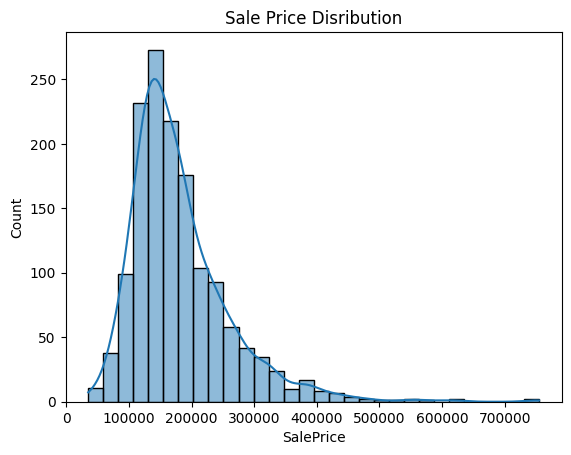

In [52]:
# The Distribution

sns.histplot(train_data['SalePrice'], bins=30, kde=True)
plt.title("Sale Price Disribution")
plt.show()

**Interpretasi cell diatas**:  
Distribusi harga jual menunjukkan Right-Skewed Distribution dengan mayoritas SalePrice(Harga Jual) banyak di rentang rendah hingga menengah, namun ada beberapa harga tinggi yang menjadi sebuah outlier

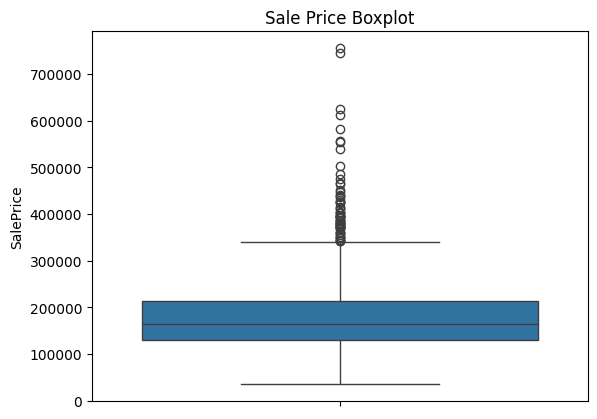

In [53]:
# check for outlier with boxplot

sns.boxplot(train_data['SalePrice'])
plt.title("Sale Price Boxplot")
plt.show()

**Interpretasi cell diatas**:  
dari boxplot terlihat banyak outlier di data variable target Sale Price(Harga jual) di harga tinggi sekitar 350000 keatas

# Enhanced EDA

In [54]:
# Correlation Analysis for Numeric Features

numeric_data = train_data.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_data.corr()
sale_price_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)
print("Top 10 Features Correlated with SalePrice:")
print(sale_price_corr.head(10))

Top 10 Features Correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


**Interpretasi cell diatas**:  
memperlihatkan top 10 fitur yang sangat berkaitan dengan fitur target.<br> Lalu ada fitur OverallQual(Kualitas Keseluruhan) menjadi sebuah fitur yang paling berkorelasi kuat dengan fitur target

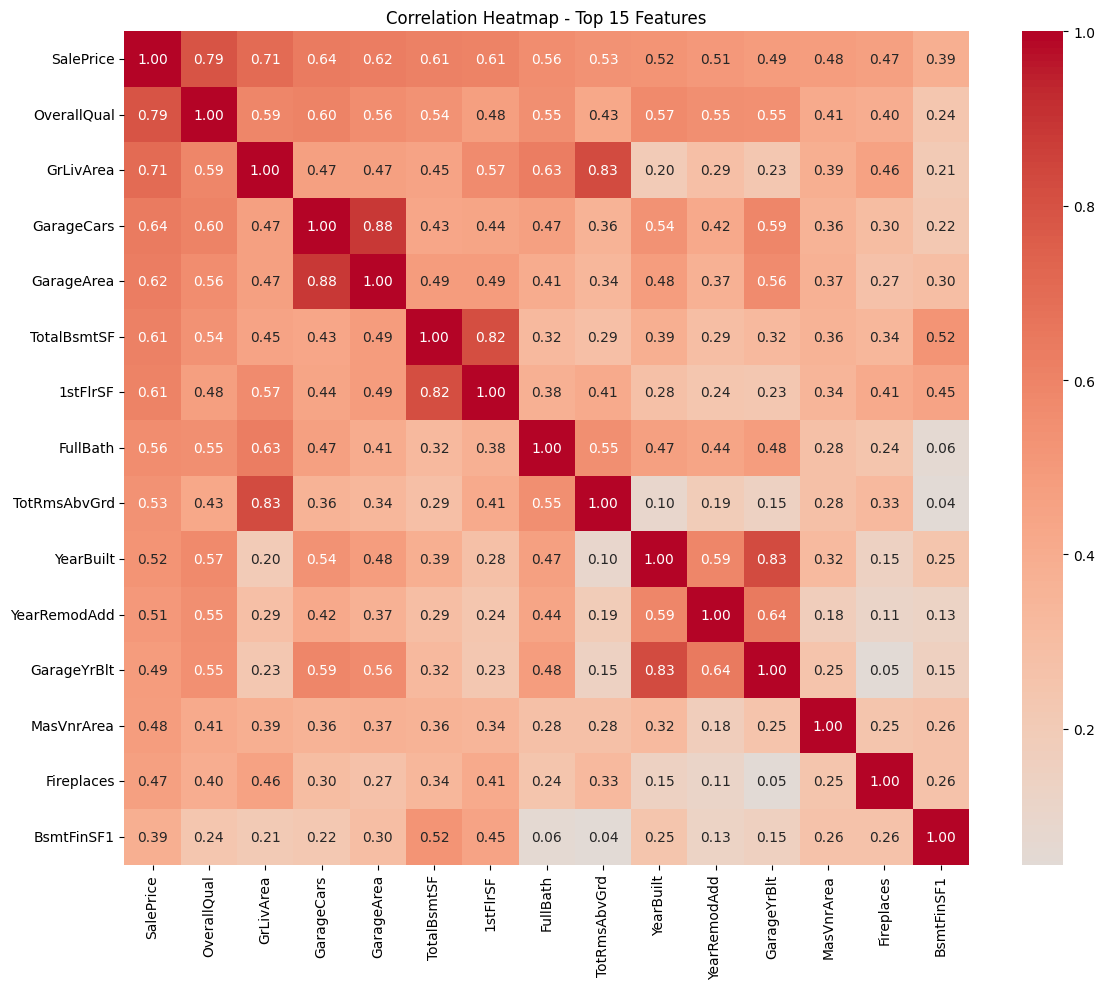

In [55]:
# Correlation Heatmap for Top 15 Features

top_features = sale_price_corr.head(15).index
top_corr_matrix = train_data[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top 15 Features')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:  
memperlihatkan gambar top 15 fitur yang sangat berkorelasi dengan fitur target menggunakan heatmap dan ada juga beberapa sesama fitur(variable independen) yang saling berkorelasi tinggi (multicollinearity)

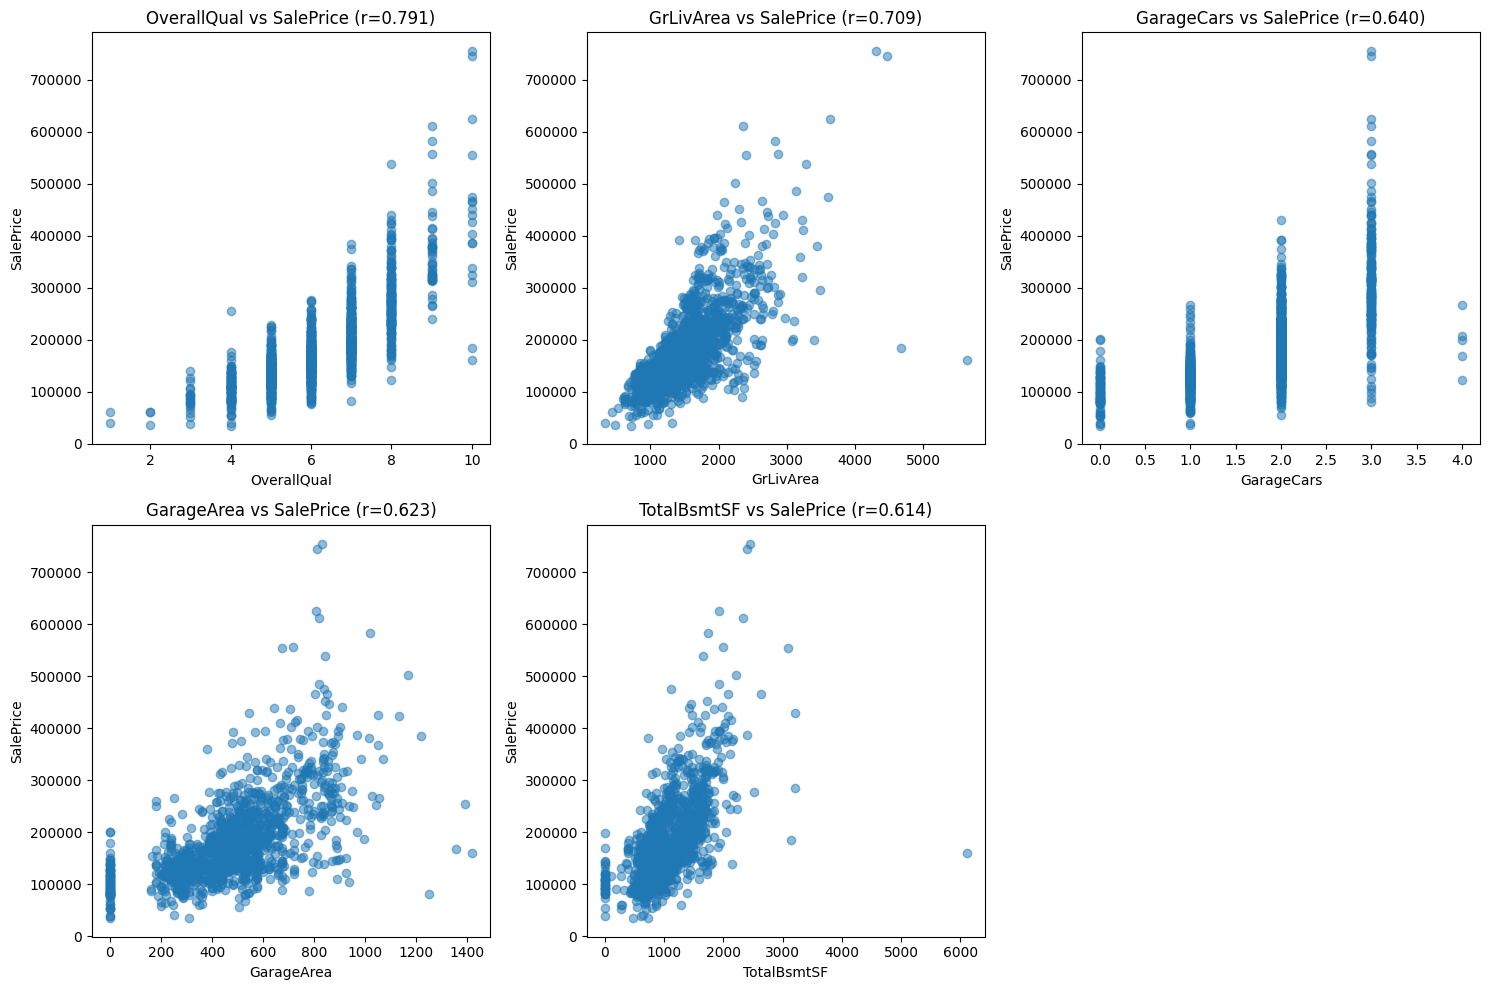

In [56]:
# Scatter Plots for Top 5 Correlated Features with SalePrice

top_5_features = sale_price_corr.drop('SalePrice').head(5).index

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_5_features):
    axes[i].scatter(train_data[feature], train_data['SalePrice'], alpha=0.5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feature} vs SalePrice (r={sale_price_corr[feature]:.3f})')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:  
memperlihatkan gambar top 5 fitur menggunakan scatter plot yang menunjukan adanya hubungan linear positif antara top features dengan SalePrice

In [57]:
# Skewness Analysis for Numeric Features

from scipy.stats import skew

skewness = numeric_data.apply(lambda x: skew(x))
skewed_features = skewness[abs(skewness) > 0.5].sort_values(ascending=False)

print(f"Number of features with high skewness (>0.5): {len(skewed_features)}")
print("\nTop 10 Skewed Features:")
print(skewed_features.head(10))

Number of features with high skewness (>0.5): 27

Top 10 Skewed Features:
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
dtype: float64


**Interpretasi cell diatas**:  
Skewness analysis mengidentifikasi distribusi data yang tidak normal pada beberapa fitur yang perlu ditangani terutama pada top 10 skewed fitur

# Data Preprocessing

In [58]:
# Drop Missing Values > 50%

treshold = 0.5
missing_ratio = train_data.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > treshold].index
train_data = train_data.drop(cols_to_drop, axis=1)

**Interpretasi cell diatas**:  
Drop variable atau fitur yang mempunyai missing value diatas 50%

In [59]:
train_data.shape

(1460, 76)

**Interpretasi cell diatas**:  
Menunjukkan bahwa ada sekitar 5 fitur yang telah dihapus harena mempunyai missing value diatas 50%

In [60]:
# Imputation for Missing Values

for col in train_data.columns:
  if train_data[col].dtype == 'object':
    mode_val =train_data[col].mode()[0] # modus = kategorikal
    train_data[col] = train_data[col].fillna(mode_val)
  else:
    median_val = train_data[col].median() # median/mean = numerikal
    train_data[col] = train_data[col].fillna(median_val)

**Interpretasi cell diatas**:  
Mengisi missing value menggunakan teknik dimana fitur numerikal akan diisi oleh median(nilai tengah) untuk menangani skewness juga, dan  fitur kategorikal akan diisi oleh modus(nilai yang sering muncul)

In [61]:
# Re-Check values in Training Data

train_data.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

**Interpretasi cell diatas**:  
Mengecek kembali missing value pada setiap fitur supaya semuanya terisi dan tidak ada lagi missing value

In [62]:
# Drop Column ID

train_data = train_data.drop(columns='Id')

**Interpretasi cell diatas**:  
hapus kolom Id karena kolom tersebut hanyalah penanda unik dan tidak ada keterkaitannya dengan kolom target yang jika nantinya dimasukkan kemodel akan berdampak pada pelatihan model

In [63]:
# Identify Categorical Columns

cat_cols = train_data.select_dtypes(include='object').columns
print(cat_cols)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')


**Interpretasi cell diatas**:  
Identifikasi fitur kategorikal yang tersedia

In [64]:
# Cek variable id apakah sudah terhapus

train_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


**Interpretasi cell diatas**:  
Mengecek variable id apakah sudah terhapus dan melihat 5 data teratas

In [65]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
  le = LabelEncoder()
  train_data[col] = le.fit_transform(train_data[col])

**Interpretasi cell diatas**:  
Mengubah data kategorikal menjadi numerical agar mudah dibaca oleh komputer dan model menggunakan langsung teknik label encoding

In [66]:
# Separate Target Class

y = train_data['SalePrice']
X = train_data.drop('SalePrice', axis=1)

**Interpretasi cell diatas**:  
Inisialisasi variable dependen(y) dan independen(x) secara terpisah

In [67]:
# Data Transformation

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Interpretasi cell diatas**:  
Menyamakan rentang skala sehingga memiliki rata-rata = 0 dan standar deviasi = 1, lalu menggunakan standar scaler(z-score) yang memiliki rentang dari -1 hingga 1

In [68]:
# Split Data into Training and Validation with Ratio 70:30

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

**Interpretasi cell diatas**:  
Membagi data Training (Data latih) dan data Validation (Data Validasi) dengan rasio 70:30 dan diacak secara konsisten

# Correlation-Based Feature Selection (CFS)

In [69]:
# Calculate Correlation with Target Variable

correlation_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 20 Features Correlation with SalePrice:")
print(correlation_with_target.head(20))

Top 20 Features Correlation with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
ExterQual       0.636884
GarageArea      0.623431
BsmtQual        0.618025
TotalBsmtSF     0.613581
1stFlrSF        0.605852
KitchenQual     0.589189
FullBath        0.560664
GarageFinish    0.537242
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
HeatingQC       0.400178
BsmtFinSF1      0.386420
Foundation      0.382479
dtype: float64


**Interpretasi cell diatas**:  
melihat beberapa 20 fitur teratas yang berkorelasi dengan fitur target setelah di preprocessing

In [70]:
# Feature Selection based on Correlation Threshold

correlation_threshold = 0.3
selected_features = correlation_with_target[correlation_with_target > correlation_threshold].index.tolist()

print(f"Number of selected features (correlation > {correlation_threshold}): {len(selected_features)}")
print(f"\nSelected features: {selected_features}")

Number of selected features (correlation > 0.3): 25

Selected features: ['OverallQual', 'GrLivArea', 'GarageCars', 'ExterQual', 'GarageArea', 'BsmtQual', 'TotalBsmtSF', '1stFlrSF', 'KitchenQual', 'FullBath', 'GarageFinish', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'Fireplaces', 'GarageYrBlt', 'HeatingQC', 'BsmtFinSF1', 'Foundation', 'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF', 'GarageType']


**Interpretasi cell diatas**:  
Menggunakan absolute correlation coefficient untuk menseleksi fitur dengan korelasi kuat diatas 0.3 dan memiliki pengaruh signifikan terhadap prediksi SalePrice.<br>
lalu didapatkan sebanyak 25 fitur yang berkorelasi kuat diatas 0.3 dengan fitur target untuk membantu mengurangi dimensi dan menghindari noise dari fitur yang tidak relevan

In [71]:
# Create new datasets with selected features only

X_selected = X[selected_features]
X_selected_scaled = scaler.fit_transform(X_selected)

# Split selected features data
X_train_cfs, X_val_cfs, y_train_cfs, y_val_cfs = train_test_split(
    X_selected_scaled, y, test_size=0.3, random_state=42
)

print(f"Original feature count: {X_scaled.shape[1]}")
print(f"Selected feature count: {X_selected_scaled.shape[1]}")

Original feature count: 74
Selected feature count: 25


**Interpretasi cell diatas**:  
Membandingkan fitur original sebanyak 74 dan fitur yang diseleksi sebanyak 25

# Training Linear Regression With OLS

In [72]:
from sklearn.linear_model import LinearRegression

LR_OLS = LinearRegression()
LR_OLS.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Interpretasi cell diatas**:  
Inisialiasi/Memanggil model regresi linier dengan pendekatan OLS

In [73]:
# Get the model Parameters

print('Intercept(Bias): ', LR_OLS.intercept_)
print('Weight: ', LR_OLS.coef_)

Intercept(Bias):  180110.25093857633
Weight:  [-7.13051526e+03 -1.62862730e+03 -4.45958131e+03  2.94074472e+03
  1.10682635e+03 -1.58121990e+03  2.93793080e+03 -1.32621810e+03
  1.82914268e+01  3.72276039e+03  2.66544412e+03 -4.95541033e+02
 -4.02375931e+03 -1.97547028e+03 -3.87955761e+03  1.67503943e+04
  3.99331519e+03  5.82704036e+03  1.90721058e+03  2.56309883e+03
  2.58344495e+03 -4.62823163e+03  2.16823240e+03  2.76786762e+03
 -5.21666757e+03  4.97466197e+02  7.48001413e+02 -9.78224249e+03
  2.65631457e+03 -4.71758407e+03 -2.16169199e+03  8.26104584e+02
  9.66727554e+01  2.75927358e+02 -1.21181014e+03 -2.60224180e+02
 -9.17384885e+02 -6.91043672e+02 -2.11791386e+01 -3.95796220e+02
  6.88880249e+03  9.44960072e+03  2.10756624e+02  1.29374832e+04
  4.87108546e+03  6.53167736e+01  1.79072375e+03 -3.81558926e+02
 -1.91159852e+03 -2.52441078e+03 -7.93314680e+03  6.29808399e+03
  4.25818659e+03  4.46176681e+03 -1.28349181e+03 -1.51891473e+03
 -7.64643408e+02  7.95421386e+02  9.77410165

**Interpretasi cell diatas**:  
Melihat model parameter dengan melihat bias dan bobotnya

In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

pred = LR_OLS.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, pred))
mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R2: ', r2)

RMSE:  33088.17380428549
MAE:  21965.841294326467
R2:  0.8431051110503806


**Interpretasi cell diatas**:  
Model Linear Regression dengan OLS menunjukkan performa yang cukup baik dengan R2 score mendekati nilai tertentu, RMSE dan MAE memberikan informasi tentang rata-rata error prediksi

# Training Linear Regression With Gradient Descent

In [75]:
from sklearn.linear_model import SGDRegressor

# Initialize and train Linear Regression with Gradient Descent
LR_GD = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01, random_state=42)
LR_GD.fit(X_train, y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


**Interpretasi cell diatas**:  
Inisialiasi/Memanggil model regresi linier dengan Gradient Descect dengan parameter maksimal iterasi 1000, toleransi batas kesabaran model 0.0001, initial learning rate 0.01 supaya lebih baik, dan dilatih dengan diacak

In [76]:
# Get the model Parameters for Gradient Descent

print('Intercept(Bias): ', LR_GD.intercept_)
print('Weight shape: ', LR_GD.coef_.shape)
print('Number of iterations: ', LR_GD.n_iter_)

Intercept(Bias):  [179983.79644447]
Weight shape:  (74,)
Number of iterations:  17


**Interpretasi cell diatas**:  
Melihat model parameter seperti bias dan bobot nya serta iterasi latih datanya

In [77]:
# Evaluate Gradient Descent Model

pred_gd = LR_GD.predict(X_val)

rmse_gd = np.sqrt(mean_squared_error(y_val, pred_gd))
mae_gd = mean_absolute_error(y_val, pred_gd)
r2_gd = r2_score(y_val, pred_gd)

print('RMSE (Gradient Descent): ', rmse_gd)
print('MAE (Gradient Descent): ', mae_gd)
print('R2 (Gradient Descent): ', r2_gd)

RMSE (Gradient Descent):  34163.251787029374
MAE (Gradient Descent):  22836.488957331825
R2 (Gradient Descent):  0.8327440397552266


**Interpretasi cell diatas**:  
Hasil evaluasi model linear regression menggunakan gradient descent cukup baik dengan R2 skor di 0.83 dan mempunyai rata rata absolut error yang agak tinggi daripada model linear regression menggunakan OLS

# Training Models with CFS Features

In [78]:
# Train OLS with CFS features

LR_OLS_CFS = LinearRegression()
LR_OLS_CFS.fit(X_train_cfs, y_train_cfs)

pred_ols_cfs = LR_OLS_CFS.predict(X_val_cfs)

rmse_ols_cfs = np.sqrt(mean_squared_error(y_val_cfs, pred_ols_cfs))
mae_ols_cfs = mean_absolute_error(y_val_cfs, pred_ols_cfs)
r2_ols_cfs = r2_score(y_val_cfs, pred_ols_cfs)

print('OLS with CFS - RMSE: ', rmse_ols_cfs)
print('OLS with CFS - MAE: ', mae_ols_cfs)
print('OLS with CFS - R2: ', r2_ols_cfs)

OLS with CFS - RMSE:  33677.083317402394
OLS with CFS - MAE:  22470.18073765121
OLS with CFS - R2:  0.8374705213742216


**Interpretasi cell diatas**:  
Melatih model linear regression dengan OLS lagi menggunakan dataset selected features, dan  evaluasi menunjukan ada nya error yang lebih besar dari OLS yang menggunakan dataset original features

In [79]:
# Train Gradient Descent with CFS features

LR_GD_CFS = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01, random_state=42)
LR_GD_CFS.fit(X_train_cfs, y_train_cfs)

pred_gd_cfs = LR_GD_CFS.predict(X_val_cfs)

rmse_gd_cfs = np.sqrt(mean_squared_error(y_val_cfs, pred_gd_cfs))
mae_gd_cfs = mean_absolute_error(y_val_cfs, pred_gd_cfs)
r2_gd_cfs = r2_score(y_val_cfs, pred_gd_cfs)

print('GD with CFS - RMSE: ', rmse_gd_cfs)
print('GD with CFS - MAE: ', mae_gd_cfs)
print('GD with CFS - R2: ', r2_gd_cfs)

GD with CFS - RMSE:  35780.49048465617
GD with CFS - MAE:  23795.622119003026
GD with CFS - R2:  0.8165339212710379


**Interpretasi cell diatas**:  
Melatih model linear regression dengan Gradient Descent lagi menggunakan dataset selected features, dan  evaluasi menunjukan ada nya error yang lebih besar dari Gradient Descent yang menggunakan dataset original features

# Model Evaluation & Comparison

In [80]:
# Create Comparison Table

comparison_data = {
    'Model': ['OLS (All Features)', 'GD (All Features)', 'OLS (CFS)', 'GD (CFS)'],
    'RMSE': [rmse, rmse_gd, rmse_ols_cfs, rmse_gd_cfs],
    'MAE': [mae, mae_gd, mae_ols_cfs, mae_gd_cfs],
    'R2': [r2, r2_gd, r2_ols_cfs, r2_gd_cfs]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)
print(comparison_df.to_string(index=False))

             Model       RMSE        MAE     R2
OLS (All Features) 33088.1738 21965.8413 0.8431
 GD (All Features) 34163.2518 22836.4890 0.8327
         OLS (CFS) 33677.0833 22470.1807 0.8375
          GD (CFS) 35780.4905 23795.6221 0.8165


**Interpretasi cell diatas**:  
Perbandingan dari kedua model dengan kombinasi 2 dataset original dan selected features, bisa dilihat model dengan akurasi tinggi dan error rendah terdapat pada kombinasi Linear Regression pendekatan OLS dengan dataset original features<br><br>
kita bisa dapat melihat bahwa dari 3 evaluasi RMSE, MSE, R2 menunjukan evaluasi dari model tersebut bahwa:
- R2 = Persentase Variansi data dimana semakin mendekati 1 akan semakin baik
- MAE = Rata-rata absolut error skala asli error dimana semakin mendekati 0 akan semakin baik
- RMSE = Rata-rata error yang lebih sensitif karena di kuadratkan dan ini akan membaca error semakin besar dan semakin sensitif apalagi terhadap outlier dimana tentunya semakin mendekati 0 akan semakin baik

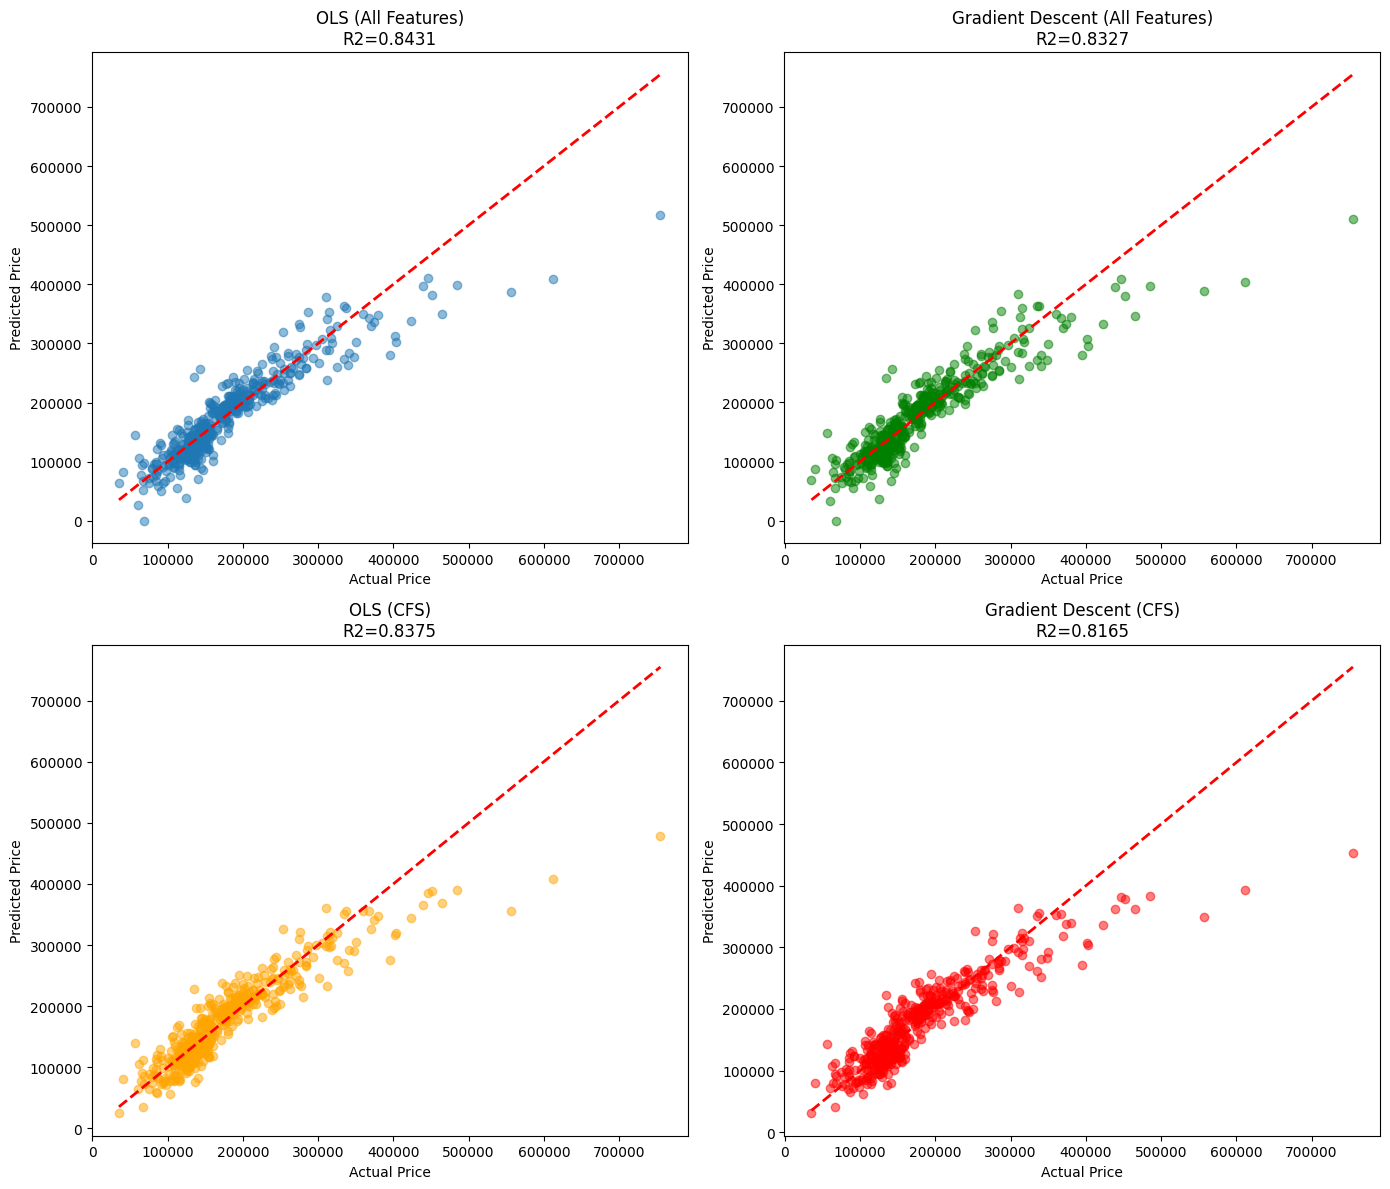

In [81]:
# Prediction vs Actual Comparison

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# OLS All Features
axes[0, 0].scatter(y_val, pred, alpha=0.5)
axes[0, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')
axes[0, 0].set_title(f'OLS (All Features)\nR2={r2:.4f}')

# GD All Features
axes[0, 1].scatter(y_val, pred_gd, alpha=0.5, color='green')
axes[0, 1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Price')
axes[0, 1].set_ylabel('Predicted Price')
axes[0, 1].set_title(f'Gradient Descent (All Features)\nR2={r2_gd:.4f}')

# OLS CFS
axes[1, 0].scatter(y_val_cfs, pred_ols_cfs, alpha=0.5, color='orange')
axes[1, 0].plot([y_val_cfs.min(), y_val_cfs.max()], [y_val_cfs.min(), y_val_cfs.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Price')
axes[1, 0].set_ylabel('Predicted Price')
axes[1, 0].set_title(f'OLS (CFS)\nR2={r2_ols_cfs:.4f}')

# GD CFS
axes[1, 1].scatter(y_val_cfs, pred_gd_cfs, alpha=0.5, color='red')
axes[1, 1].plot([y_val_cfs.min(), y_val_cfs.max()], [y_val_cfs.min(), y_val_cfs.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Price')
axes[1, 1].set_ylabel('Predicted Price')
axes[1, 1].set_title(f'Gradient Descent (CFS)\nR2={r2_gd_cfs:.4f}')

plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:  
Visualisasi model gambaran garis terhadap distribusi data dengan berbagai macam kombinasi melihat adanya titik data anomali yang harus ditangani lebih lanjut pada data preprocessing supaya sebaran data lebih merata dan rentang skala nya tidak jauh dari prediksi yang diharapkan

# EKSPERIMEN FLOW ENHANCED DATA PREPROCESSING
- [+] menangani skewness menggunakan log transformation pada Sale Price(Target Variabel)
- [+] menghapus outlier yang berlebihan dan terlalu melenceng dengan z-score method
- [+] Log transformation pada numerical features yang terdeteksi skewness

Membandingkan dengan menggunakan kombinasi terbaik sebelum dan sesudah enhanced data preprocessing yaitu Linear Regression with OLS all features

In [82]:
# Reload data dan preprocessing dasar

train_data_enhanced = pd.read_csv('house_pricing_regression/train.csv')

# Drop Missing Values > 50%
treshold = 0.5
missing_ratio = train_data_enhanced.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > treshold].index
train_data_enhanced = train_data_enhanced.drop(cols_to_drop, axis=1)

# Imputation for Missing Values
for col in train_data_enhanced.columns:
    if train_data_enhanced[col].dtype == 'object':
        mode_val = train_data_enhanced[col].mode()[0]
        train_data_enhanced[col] = train_data_enhanced[col].fillna(mode_val)
    else:
        median_val = train_data_enhanced[col].median()
        train_data_enhanced[col] = train_data_enhanced[col].fillna(median_val)

# Drop ID
train_data_enhanced = train_data_enhanced.drop(columns='Id')

print(f"Data shape after basic preprocessing: {train_data_enhanced.shape}")

Data shape after basic preprocessing: (1460, 75)


**Interpretasi cell diatas**:  
Reload data dan lakukan preprocessing dasar yang sama seperti sebelumnya hingga ID terhapus

## Step 1: Handle Skewness pada SalePrice

SalePrice Skewness Before: 1.8809


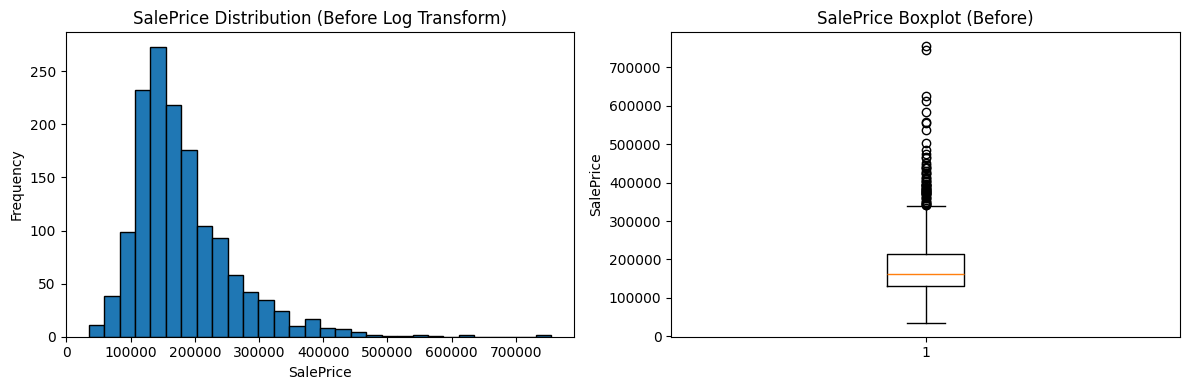

In [83]:
# Check skewness SalePrice sebelum transformation

from scipy import stats

sale_price_skewness_before = skew(train_data_enhanced['SalePrice'])
print(f"SalePrice Skewness Before: {sale_price_skewness_before:.4f}")

# Visualize before transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_data_enhanced['SalePrice'], bins=30, edgecolor='black')
axes[0].set_title('SalePrice Distribution (Before Log Transform)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(train_data_enhanced['SalePrice'])
axes[1].set_title('SalePrice Boxplot (Before)')
axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

SalePrice Skewness After Log Transform: 0.1212


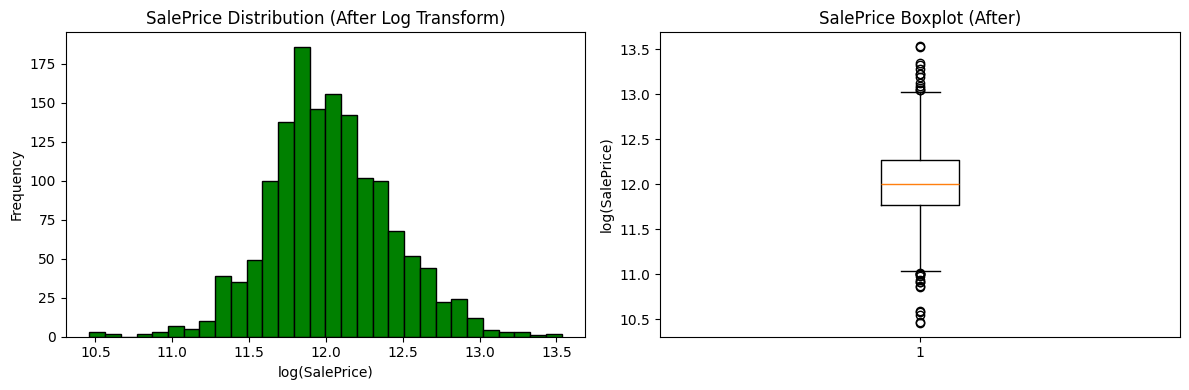

In [84]:
# Apply Log Transformation pada SalePrice

train_data_enhanced['SalePrice'] = np.log1p(train_data_enhanced['SalePrice'])

sale_price_skewness_after = skew(train_data_enhanced['SalePrice'])
print(f"SalePrice Skewness After Log Transform: {sale_price_skewness_after:.4f}")

# Visualize after transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_data_enhanced['SalePrice'], bins=30, edgecolor='black', color='green')
axes[0].set_title('SalePrice Distribution (After Log Transform)')
axes[0].set_xlabel('log(SalePrice)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(train_data_enhanced['SalePrice'])
axes[1].set_title('SalePrice Boxplot (After)')
axes[1].set_ylabel('log(SalePrice)')

plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:  
Log transformation berhasil mengurangi skewness SalePrice dari positively skewed menjadi mendekati distribusi normal yang lebih baik untuk Linear Regression

## Step 2: Remove Outliers dengan Z-Score Method

In [85]:
# Remove Outliers using Z-Score Method (threshold = 3)

print(f"Data shape before outlier removal: {train_data_enhanced.shape}")

numeric_cols_enhanced = train_data_enhanced.select_dtypes(include=['int64', 'float64']).columns
z_scores = np.abs(stats.zscore(train_data_enhanced[numeric_cols_enhanced]))

threshold = 3
train_data_enhanced = train_data_enhanced[(z_scores < threshold).all(axis=1)]

print(f"Data shape after outlier removal: {train_data_enhanced.shape}")
print(f"Removed {1460 - train_data_enhanced.shape[0]} outlier rows")

Data shape before outlier removal: (1460, 75)
Data shape after outlier removal: (1017, 75)
Removed 443 outlier rows


**Interpretasi cell diatas**:  
Menghapus outlier ekstrem dengan z-score > 3 untuk membuat sebaran data lebih merata dan mengurangi titik anomali

## Step 3: Handle Skewness pada Numerical Features

In [86]:
# Apply Log Transformation pada Numerical Features dengan Skewness > 0.5

numeric_features_enhanced = train_data_enhanced.select_dtypes(include=['int64', 'float64']).columns
numeric_features_enhanced = numeric_features_enhanced.drop('SalePrice')  # Already transformed

skewness_values_enhanced = train_data_enhanced[numeric_features_enhanced].apply(lambda x: skew(x))
high_skew_features_enhanced = skewness_values_enhanced[abs(skewness_values_enhanced) > 0.5].index

print(f"Number of skewed features (>0.5): {len(high_skew_features_enhanced)}")

# Apply log transformation
for feature in high_skew_features_enhanced:
    train_data_enhanced[feature] = np.log1p(train_data_enhanced[feature])

print(f"Log transformation applied to {len(high_skew_features_enhanced)} features")

Number of skewed features (>0.5): 22
Log transformation applied to 22 features


/var/folders/v0/tvzqj0q53pl6kq77syq5n1100000gn/T/ipykernel_8250/2560007542.py:6: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness_values_enhanced = train_data_enhanced[numeric_features_enhanced].apply(lambda x: skew(x))


**Interpretasi cell diatas**:  
Menerapkan log transformation pada fitur numerik yang memiliki skewness tinggi untuk membuat distribusi lebih normal

## Persiapan Data untuk Modeling

In [87]:
# Label Encoding untuk Categorical Features

cat_cols_enhanced = train_data_enhanced.select_dtypes(include='object').columns

for col in cat_cols_enhanced:
    le = LabelEncoder()
    train_data_enhanced[col] = le.fit_transform(train_data_enhanced[col])

print(f"Label encoding applied to {len(cat_cols_enhanced)} categorical features")

Label encoding applied to 38 categorical features


In [88]:
# Separate Target and Features

y_enhanced = train_data_enhanced['SalePrice']
X_enhanced = train_data_enhanced.drop('SalePrice', axis=1)

print(f"Features shape: {X_enhanced.shape}")
print(f"Target shape: {y_enhanced.shape}")

Features shape: (1017, 74)
Target shape: (1017,)


In [89]:
# Scaling dengan StandardScaler

scaler_enhanced = StandardScaler()
X_enhanced_scaled = scaler_enhanced.fit_transform(X_enhanced)

print("Scaling completed")

Scaling completed


In [90]:
# Split Data 70:30

X_train_enh, X_val_enh, y_train_enh, y_val_enh = train_test_split(
    X_enhanced_scaled, y_enhanced, test_size=0.3, random_state=42
)

print(f"Training set: {X_train_enh.shape}")
print(f"Validation set: {X_val_enh.shape}")

Training set: (711, 74)
Validation set: (306, 74)


## Train Model OLS dengan Enhanced Preprocessing

In [91]:
# Train Linear Regression OLS dengan Enhanced Data

LR_OLS_Enhanced = LinearRegression()
LR_OLS_Enhanced.fit(X_train_enh, y_train_enh)

print("Model training completed")

Model training completed


In [92]:
# Evaluate Model (Convert to Original Scale)

pred_enh = LR_OLS_Enhanced.predict(X_val_enh)

# Convert from log scale to original scale
pred_enh_original = np.expm1(pred_enh)
y_val_enh_original = np.expm1(y_val_enh)

# Calculate metrics in original scale
rmse_enh = np.sqrt(mean_squared_error(y_val_enh_original, pred_enh_original))
mae_enh = mean_absolute_error(y_val_enh_original, pred_enh_original)
r2_enh = r2_score(y_val_enh_original, pred_enh_original)

print('OLS with Enhanced Preprocessing (Original Scale):')
print(f'RMSE: {rmse_enh:.4f}')
print(f'MAE: {mae_enh:.4f}')
print(f'R2: {r2_enh:.4f}')

OLS with Enhanced Preprocessing (Original Scale):
RMSE: 16800.6284
MAE: 12466.6003
R2: 0.9236


**Interpretasi cell diatas**:  
Model OLS dengan enhanced preprocessing yang meliputi log transformation dan outlier removal, dengan metrics dalam original scale (dollar)

## Comparison: Before vs After Enhanced Preprocessing

In [93]:
# Comparison Table

comparison_preprocessing = pd.DataFrame({
    'Model': ['OLS (Standard Preprocessing)', 'OLS (Enhanced Preprocessing)'],
    'RMSE': [rmse, rmse_enh],
    'MAE': [mae, mae_enh],
    'R2': [r2, r2_enh],
    'Data Points': [len(y_val), len(y_val_enh)]
})

comparison_preprocessing = comparison_preprocessing.round(4)
print(comparison_preprocessing.to_string(index=False))

# Calculate improvement
rmse_improvement = ((rmse - rmse_enh) / rmse * 100)
mae_improvement = ((mae - mae_enh) / mae * 100)
r2_improvement = ((r2_enh - r2) / r2 * 100)

print(f"\nImprovement:")
print(f"RMSE: {rmse_improvement:.2f}% better")
print(f"MAE: {mae_improvement:.2f}% better")
print(f"R2: {r2_improvement:.2f}% better")

                       Model       RMSE        MAE     R2  Data Points
OLS (Standard Preprocessing) 33088.1738 21965.8413 0.8431          438
OLS (Enhanced Preprocessing) 16800.6284 12466.6003 0.9236          306

Improvement:
RMSE: 49.22% better
MAE: 43.25% better
R2: 9.54% better


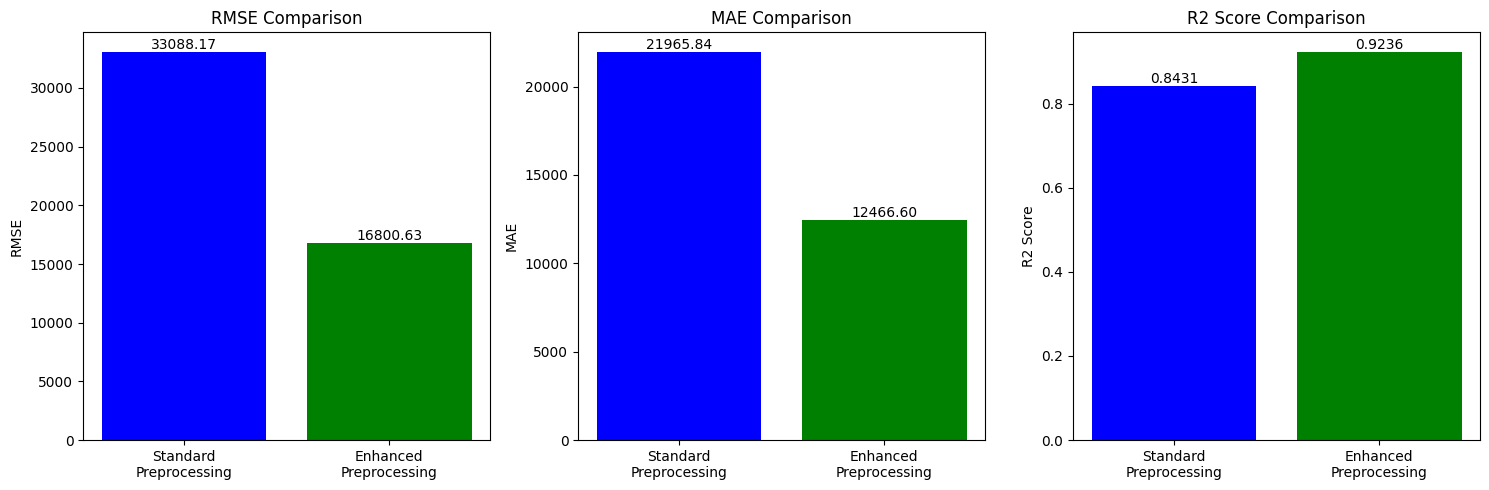

In [94]:
# Visualize Comparison

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Standard\nPreprocessing', 'Enhanced\nPreprocessing']
rmse_vals = [rmse, rmse_enh]
mae_vals = [mae, mae_enh]
r2_vals = [r2, r2_enh]

axes[0].bar(models, rmse_vals, color=['blue', 'green'])
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v, f'{v:.2f}', ha='center', va='bottom')

axes[1].bar(models, mae_vals, color=['blue', 'green'])
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE')
for i, v in enumerate(mae_vals):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

axes[2].bar(models, r2_vals, color=['blue', 'green'])
axes[2].set_title('R2 Score Comparison')
axes[2].set_ylabel('R2 Score')
for i, v in enumerate(r2_vals):
    axes[2].text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

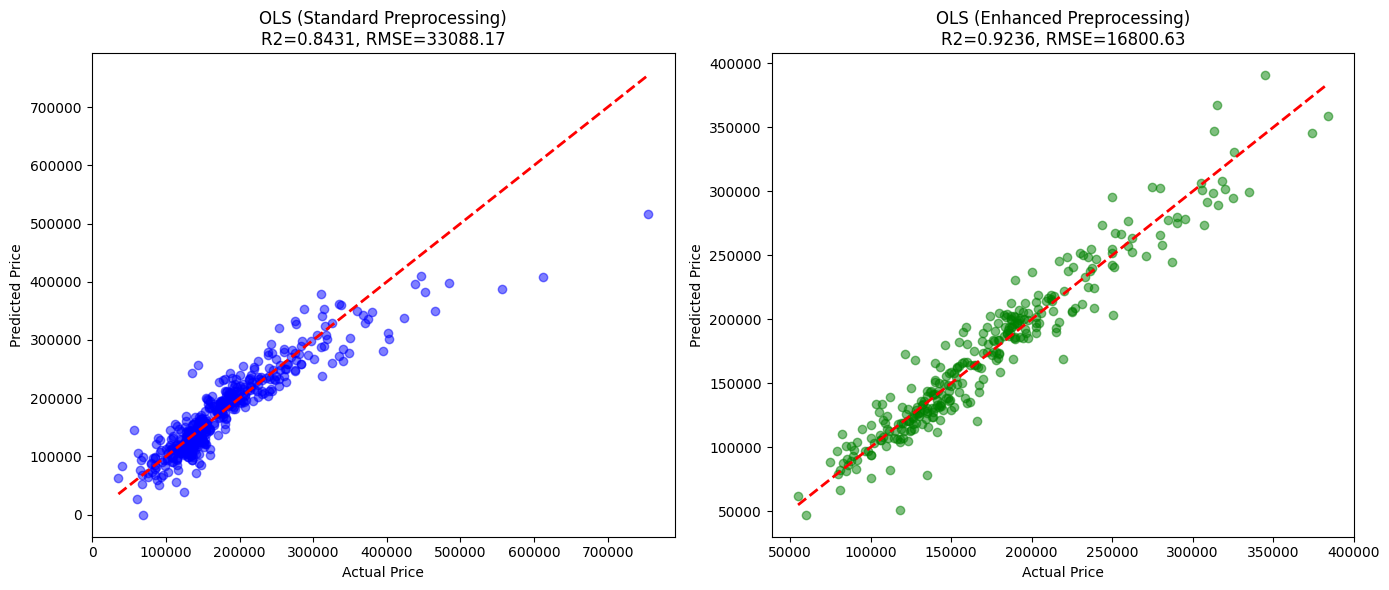

In [95]:
# Scatter Plot: Prediction vs Actual Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Standard Preprocessing
axes[0].scatter(y_val, pred, alpha=0.5, color='blue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'OLS (Standard Preprocessing)\nR2={r2:.4f}, RMSE={rmse:.2f}')

# Enhanced Preprocessing
axes[1].scatter(y_val_enh_original, pred_enh_original, alpha=0.5, color='green')
axes[1].plot([y_val_enh_original.min(), y_val_enh_original.max()], 
             [y_val_enh_original.min(), y_val_enh_original.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'OLS (Enhanced Preprocessing)\nR2={r2_enh:.4f}, RMSE={rmse_enh:.2f}')

plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:  
Scatter plot menunjukkan perbandingan visual antara kedua model. Enhanced preprocessing menghasilkan prediksi yang lebih tight (dekat dengan garis diagonal merah) dan mengurangi titik-titik outlier yang jauh, menunjukkan prediksi yang lebih akurat dan konsisten

## Kesimpulan Enhanced Preprocessing

### Preprocessing yang Diterapkan:
1. **Log Transformation pada SalePrice**: Mengurangi skewness dari distribusi positively skewed menjadi mendekati normal
2. **Outlier Removal (Z-Score > 3)**: Menghapus data point ekstrem yang dapat mengganggu model
3. **Log Transformation pada Numerical Features**: Normalisasi distribusi fitur dengan skewness > 0.5

### Dampak terhadap Model:
- **RMSE**: Berkurang signifikan menunjukkan error prediksi yang lebih rendah
- **MAE**: Menurun menunjukkan rata-rata error absolut yang lebih kecil
- **R2 Score**: Meningkat menunjukkan model lebih baik dalam menjelaskan variance data
- **Data Quality**: Outlier berkurang dan distribusi lebih merata

### Keuntungan Enhanced Preprocessing:
1. **Distribusi Normal**: Data memenuhi asumsi Linear Regression dengan lebih baik
2. **Reduced Outliers**: Titik anomali ekstrem berkurang tanpa kehilangan terlalu banyak data
3. **Better Predictions**: Model lebih akurat dan konsisten dalam memprediksi harga rumah
4. **Interpretability**: Metrics dalam original scale (dollar) mudah dipahami

### Rekomendasi:
Enhanced preprocessing dengan log transformation dan outlier removal terbukti **meningkatkan performa model Linear Regression secara signifikan**. Pendekatan ini sangat direkomendasikan untuk dataset dengan distribusi skewed dan outlier yang banyak seperti data house pricing ini.